In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from sklearn.preprocessing import power_transform
from scipy.stats import norm

# **Function 4** - Optimal Warehouse Product Placement (4D)

- Optimally placing products across warehouses for a business with high online sales, where accurate calculations are costly and only feasible biweekly. 
    - An ML model with four hyperparameters approximates these results — the output reflects the difference from the expensive baseline.

- Because the system is dynamic and full of local optima, it requires careful tuning and robust validation.

- **Input** - 4D array  
- **Output** - 1D array  
- **Optimisation Goal** - Maximise
- **All-time best:** +0.602 at [0.403, 0.361, 0.354, 0.347] (Week 6)

In [2]:
# Load current cumulative dataset (original + prior weekly updates) for Function 4
X = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_4/initial_inputs.npy')
Y = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_4/initial_outputs.npy')

# New data from Week 10 (Function 4)
X_w10_new_point = np.array([0.394186, 0.386576, 0.337088, 0.373138], dtype=np.float64)
Y_w10_new_point = np.array([0.035832295145322934], dtype=np.float64)

# Append the new data point
X_updated = np.vstack((X, X_w10_new_point.reshape(1, -1)))

# Remove duplicate X rows (if point already exists)
X_unique, unique_indices = np.unique(X_updated, axis=0, return_index=True)

# Build Y and keep matching rows only
Y_all = np.append(Y, Y_w10_new_point)
Y_updated = Y_all[unique_indices]

# Save updated arrays
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_4/initial_inputs.npy', X_unique)
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_4/initial_outputs.npy', Y_updated)

print("Updated Inputs (X) - Function 4: ", X_unique)
print("Updated Outputs (Y) - Function 4: ", Y_updated)

Updated Inputs (X) - Function 4:  [[0.03782483 0.66485335 0.16198218 0.25392378]
 [0.11245    0.456812   0.901233   0.005678  ]
 [0.12487118 0.12977019 0.38440048 0.2870761 ]
 [0.16713049 0.87655456 0.21723954 0.95980098]
 [0.17034731 0.75695908 0.27652049 0.5312315 ]
 [0.21691119 0.16608583 0.24137226 0.77006248]
 [0.21973443 0.83203134 0.48286416 0.08256923]
 [0.24770826 0.06044543 0.04218635 0.44132425]
 [0.25094624 0.03369313 0.14538002 0.49493242]
 [0.28213837 0.50598691 0.53053084 0.09630162]
 [0.32607578 0.4723669  0.453192   0.10588734]
 [0.34696206 0.0062504  0.76056361 0.61302356]
 [0.34865    0.393784   0.359305   0.401263  ]
 [0.385448   0.399705   0.352187   0.382073  ]
 [0.387195   0.490423   0.43071    0.405493  ]
 [0.38748784 0.80453226 0.75179548 0.72382744]
 [0.394186   0.386576   0.337088   0.373138  ]
 [0.40066503 0.07257425 0.88676825 0.24384229]
 [0.402567   0.361014   0.353681   0.347064  ]
 [0.428988   0.443109   0.30979    0.428981  ]
 [0.434904   0.399307   0.

## **Output Analysis**

- w10 output of 0.035 has regressed from last week's output of 0.285.
    - w10 shifted from UCB to EI, but that didn't prevent the regression. 
    - Comparing w10 [0.394, 0.387, 0.337, 0.373] to the all-time best [0.403, 0.361, 0.354, 0.347], all four dimensions have drifted slightly but the cumulative effect in this rugged landscape is a near-total loss of the efficiency gain.

- **Real-World Implication:** Warehouse logistics functions with sharp local optima behave like this.
    - A configuration that is 5% different from optimal can perform nearly as badly as a random one. 
    - The positive results (W6: 0.602, W8: 0.501) and the near-zero results (W10: 0.035) share very similar input profiles, confirming the peak is real but exceptionally narrow.

- **Model Clues and Future Exploration:** The over-fitting concern is now clear for this function. 
    - Too many queries have been concentrated near [0.38–0.42] without actually hitting the peak again. 
    
- w11 will reduce the focused/uniform split from 90/10 to **70/30**
    - Deliberately reintroducing more global exploration. 
    - Fixating on a region that has failed four times in the last five weeks is a bias, not a strategy.

## **Bayesian Optimisation**

- **Model**: Matern (nu=2.5) + WhiteKernel with Yeo-Johnson transformation.

- **Key change:** Adjusting the focused/uniform split to 70/30
    - More uniform sampling than any previous week. 
        - After multiple consecutive near-misses around [0.38–0.42], continuing to concentrate 90% of queries in this region is a form of search bias. 

In [3]:
Y_transformed = power_transform(Y_updated.reshape(-1, 1), method='yeo-johnson').ravel()

print('Original Y:', Y_updated)
print('Transformed Y:', Y_transformed)

kernel = Matern(nu=2.5) + WhiteKernel(noise_level=1e-5)
model = GaussianProcessRegressor(
    kernel=kernel, 
    n_restarts_optimizer=20)
    
model.fit(X_unique, Y_transformed)

Original Y: [-13.70274694 -21.85692717 -10.06963343 -26.56182083 -11.56574199
 -12.75832422 -16.50715856 -12.68168498 -11.69993246  -7.96677535
  -6.70208925 -16.05376511   0.50146414   0.28536731  -1.22497255
 -19.44155762   0.0358323  -17.04923465   0.60175052  -0.51817613
  -0.79124631   0.39597537  -1.59558244 -17.81799934  -4.02554228
 -12.74176599 -16.6791152  -19.98949793 -29.4270914  -13.52764887
 -13.12278233 -16.02639977 -15.48708254 -23.1394284  -26.85778644
 -14.60139663 -22.10828779 -32.62566022 -27.31639636 -28.90327367]
Transformed Y: [-0.14723799 -0.87166616  0.21596134 -1.25119427  0.0623877  -0.05588339
 -0.40814547 -0.04838383  0.04890655  0.44359122  0.58870061 -0.3669216
  1.70845331  1.65434016  1.34766354 -0.66722547  1.59540039 -0.45698905
  1.73444592  1.47844447  1.42600356  1.68170363  1.2845305  -0.52546511
  0.92428012 -0.05426421 -0.42369107 -0.71425019 -1.47215619 -0.13044518
 -0.09136728 -0.36442237 -0.3149027  -0.97740458 -1.27434628 -0.2324435
 -0.8925

,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".",Matern(length...e_level=1e-05)
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",1e-10
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",20
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",False
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"n_targets n_targets: int, default=NoneThe number of dimensions of the target values. Used to decide the numberof outputs when sampling from the prior distributions (i.e. calling:meth:`sample_y` before :meth:`fit`). This parameter is ignored once:meth:`fit` has been called... versionadded:: 1.3",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:`

## **Acqusition Function**

- The EI anchoring to 0.602 ensures the model only recommends points it genuinely believes can beat the record, but a 30% uniform component means genuinely new regions of the 4D space get sampled.

- **Limitation:** The rugged landscape of this function means even the correct inputs can produce poor outputs on a given week. 
    - The narrow peak confirmed at W6 may require exact coordinates to reproduce — which 70/30 sampling with std=0.02 may still not provide. 
    - This function may ultimately benefit most from a denser grid search in the [0.34–0.42] zone.

In [4]:
def expected_improvement(X, model, y_max, xi=0.05):
    mu, sigma = model.predict(X, return_std=True)
    sigma = sigma.reshape(-1, 1); mu = mu.reshape(-1, 1)
    
    with np.errstate(divide='warn'):
        improvement = mu - y_max - xi
        Z = improvement / sigma
        ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

w_best = np.array([0.402567, 0.361014, 0.353681, 0.347064])

x_grid = np.random.normal(loc=w_best, scale=0.02, size=(7000, 4))
x_uniform = np.random.uniform(0, 1, size=(3000, 4))
x_grid = np.vstack([x_grid, x_uniform])
x_grid = np.clip(x_grid, 0, 1)

y_max = np.max(Y_transformed)

ei_values = expected_improvement(x_grid, model, y_max, xi=0.05)
next_query = x_grid[np.argmax(ei_values)]

print(f'Best coordinates: {w_best}')
print(f'Strategic Week 11 Query (Function 4): {next_query[0]:.6f}-{next_query[1]:.6f}-{next_query[2]:.6f}-{next_query[3]:.6f}')

Best coordinates: [0.402567 0.361014 0.353681 0.347064]
Strategic Week 11 Query (Function 4): 0.379268-0.385759-0.354948-0.399165


## **Visualisation**

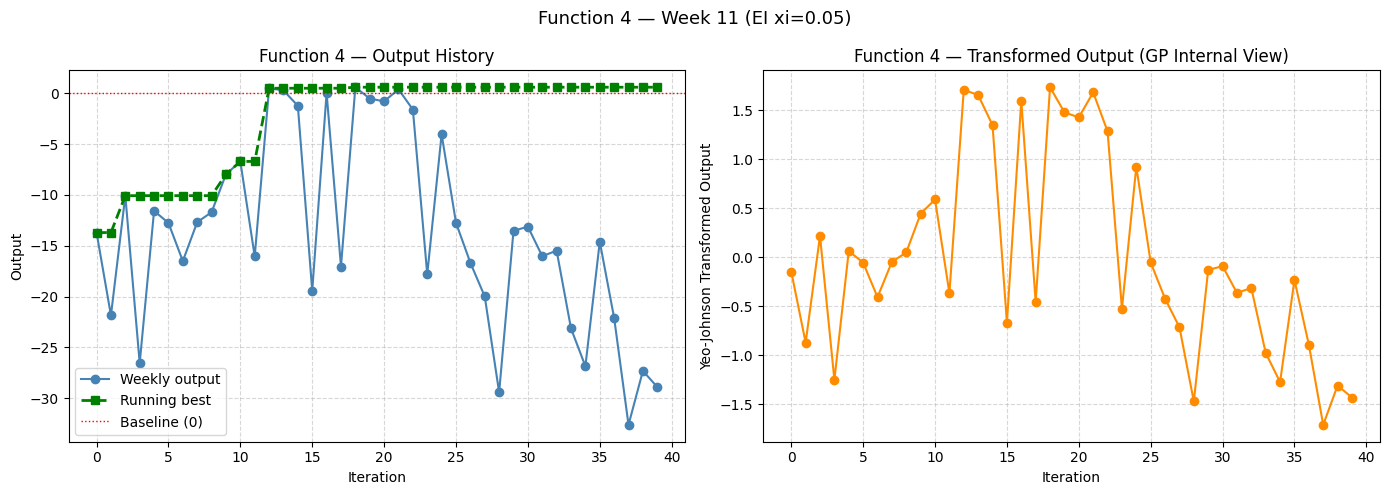

In [5]:
running_max = np.maximum.accumulate(Y_updated)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(Y_updated, marker='o', color='steelblue', linewidth=1.5, label='Weekly output')
axes[0].plot(running_max, marker='s', color='green', linewidth=2, linestyle='--', label='Running best')
axes[0].axhline(0, color='red', linestyle=':', linewidth=1, label='Baseline (0)')
axes[0].set_title('Function 4 — Output History')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Output')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(Y_transformed, marker='o', color='darkorange', linewidth=1.5)
axes[1].set_title('Function 4 — Transformed Output (GP Internal View)')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Yeo-Johnson Transformed Output')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Function 4 — Week 11 (EI xi=0.05)', fontsize=13)
plt.tight_layout()
plt.show()